In [25]:
from pathlib import Path
import pyvcell.vcml as vc
import basico

# Model imported from VCell

In [26]:
biomodel = vc.load_vcml_file("../models/Tutorial_MultiApp_PDE.vcml")
model = biomodel.model
display(biomodel)
display(model.parameter_values)

Biomodel(model=Model(compartments=['cyt', 'nuc', 'EC', 'pm', 'nm'], species=['Ran_cyt', 'C_cyt', 'RanC_nuc', 'RanC_cyt'], reactions=['r0', 'flux0'], parameters=[]), applications=['3D pde'], simulations=['Simulation4'])

{'r0.J': '((Kf * RanC_cyt) - ((Kr * Ran_cyt) * C_cyt))',
 'r0.Kf': 1.0,
 'r0.Kr': 1000.0,
 'flux0.J': '(kfl * (RanC_cyt - RanC_nuc))',
 'flux0.I': 0.0,
 'flux0.netValence': 1.0,
 'flux0.kfl': 2.0}

In [27]:
model.set_parameter_value(name="r0.Kf", value=20.0)
display(model.parameter_values)

{'r0.J': '((Kf * RanC_cyt) - ((Kr * Ran_cyt) * C_cyt))',
 'r0.Kf': 20.0,
 'r0.Kr': 1000.0,
 'flux0.J': '(kfl * (RanC_cyt - RanC_nuc))',
 'flux0.I': 0.0,
 'flux0.netValence': 1.0,
 'flux0.kfl': 2.0}

# load into Copasi - not working for me

In [28]:
# run N=10 simulations with random r0.Kf parameter value and collect mean concentrations
N=10
import random
import numpy as np

sim_name = biomodel.applications[0].simulations[0].name
r0_Kf_values = np.random.lognormal(mean=0, sigma=1.0, size=N)
all_results = []
for val in r0_Kf_values:
    model.set_parameter_value("r0.Kf", val)
    print(f"running sim with r0.Kf={val}")
    all_results.append(vc.simulate(biomodel, sim_name))

running sim with r0.Kf=1.595466965370271
Found shared library: /Users/jimschaff/Documents/workspace/pyvcell/.venv_jupyter/lib/python3.11/site-packages/libvcell/lib/libvcell.dylib
2025-04-14T03:49:01.669922Z main WARN The use of package scanning to locate Log4j plugins is deprecated.
Please remove the `packages` attribute from your configuration file.
See https://logging.apache.org/log4j/2.x/faq.html#package-scanning for details.
2025-04-14T03:49:01.675947Z main WARN The Logger cbit.vcell.model.Kinetics was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@1351b682 and is now requested with a null message factory (defaults to org.apache.logging.log4j.message.ParameterizedMessageFactory), which may create log events with unexpected formatting.
2025-04-14T03:49:01.992696Z main WARN The Logger cbit.vcell.mapping.AbstractMathMapping was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@1351b682 and is now requeste

Simulation Complete in Main() ... 


running sim with r0.Kf=4.829766986309707
Found shared library: /Users/jimschaff/Documents/workspace/pyvcell/.venv_jupyter/lib/python3.11/site-packages/libvcell/lib/libvcell.dylib
2025-04-14T03:49:14.282836Z main WARN The use of package scanning to locate Log4j plugins is deprecated.
Please remove the `packages` attribute from your configuration file.
See https://logging.apache.org/log4j/2.x/faq.html#package-scanning for details.
2025-04-14T03:49:14.287082Z main WARN The Logger cbit.vcell.model.Kinetics was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@3b36d6fd and is now requested with a null message factory (defaults to org.apache.logging.log4j.message.ParameterizedMessageFactory), which may create log events with unexpected formatting.
2025-04-14T03:49:14.592711Z main WARN The Logger cbit.vcell.mapping.AbstractMathMapping was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@3b36d6fd and is now requeste

Simulation Complete in Main() ... 


running sim with r0.Kf=1.1266941002336273
Found shared library: /Users/jimschaff/Documents/workspace/pyvcell/.venv_jupyter/lib/python3.11/site-packages/libvcell/lib/libvcell.dylib
2025-04-14T03:49:26.982803Z main WARN The use of package scanning to locate Log4j plugins is deprecated.
Please remove the `packages` attribute from your configuration file.
See https://logging.apache.org/log4j/2.x/faq.html#package-scanning for details.
2025-04-14T03:49:26.986499Z main WARN The Logger cbit.vcell.model.Kinetics was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@7707e8fe and is now requested with a null message factory (defaults to org.apache.logging.log4j.message.ParameterizedMessageFactory), which may create log events with unexpected formatting.
2025-04-14T03:49:27.308940Z main WARN The Logger cbit.vcell.mapping.AbstractMathMapping was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@7707e8fe and is now request

...

running sim with r0.Kf=0.44021092229024283
Found shared library: /Users/jimschaff/Documents/workspace/pyvcell/.venv_jupyter/lib/python3.11/site-packages/libvcell/lib/libvcell.dylib
2025-04-14T03:50:40.296772Z main WARN The use of package scanning to locate Log4j plugins is deprecated.
Please remove the `packages` attribute from your configuration file.
See https://logging.apache.org/log4j/2.x/faq.html#package-scanning for details.
2025-04-14T03:50:40.300337Z main WARN The Logger cbit.vcell.model.Kinetics was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@3b270a6c and is now requested with a null message factory (defaults to org.apache.logging.log4j.message.ParameterizedMessageFactory), which may create log events with unexpected formatting.
2025-04-14T03:50:40.597675Z main WARN The Logger cbit.vcell.mapping.AbstractMathMapping was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@3b270a6c and is now reques

Simulation Complete in Main() ... 


running sim with r0.Kf=2.7161175502471253
Found shared library: /Users/jimschaff/Documents/workspace/pyvcell/.venv_jupyter/lib/python3.11/site-packages/libvcell/lib/libvcell.dylib
2025-04-14T03:50:52.657380Z main WARN The use of package scanning to locate Log4j plugins is deprecated.
Please remove the `packages` attribute from your configuration file.
See https://logging.apache.org/log4j/2.x/faq.html#package-scanning for details.
2025-04-14T03:50:52.661215Z main WARN The Logger cbit.vcell.model.Kinetics was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@5a7a3806 and is now requested with a null message factory (defaults to org.apache.logging.log4j.message.ParameterizedMessageFactory), which may create log events with unexpected formatting.
2025-04-14T03:50:52.983486Z main WARN The Logger cbit.vcell.mapping.AbstractMathMapping was created with the message factory org.apache.logging.log4j.message.ReusableMessageFactory@5a7a3806 and is now request

Simulation Complete in Main() ... 


initializing mesh
numVolume=367236

CartesianMesh::computeNormalsFromNeighbors(), compute normals from neighbors
Membrane Elements -> N=16791
qhull precision warning: 
572 has 0 neighbors !
qhull precision error: initial simplex is not convex. Distance=-4.2e-16
2246 has 0 neighbors !
4422 has 0 neighbors !
13393 has 0 neighbors !
--------Num of points that have zero neighbors 4
--------Num Neighbors before symmetrize 99581
--------Num Neighbors after symmetrize 108440
Total volume=6049.231566
Total FluxArea =39.83851721
Total FluxAreaXM =0
Total FluxAreaXP =0
Total FluxAreaYM =24.25749724
Total FluxAreaYP =15.58101996
Total FluxAreaZM =0
Total FluxAreaZP =0
mesh initialized
preprocessing finished
pdeCount=4, odeCount=0
No log-file found at constructed path `/Users/jimschaff/Documents/workspace/pyvcell/examples/notebooks/workspace/out_dir_z5vjkful/SimID_129924409_0_.log`.simulation [SimID_129924409_0_] started
temporary directory used is /var/folders/zz/gcfcvgtd5v1cdgj2sw4bjzdr0000gr/T/

r0.Kf=1.595466965370271


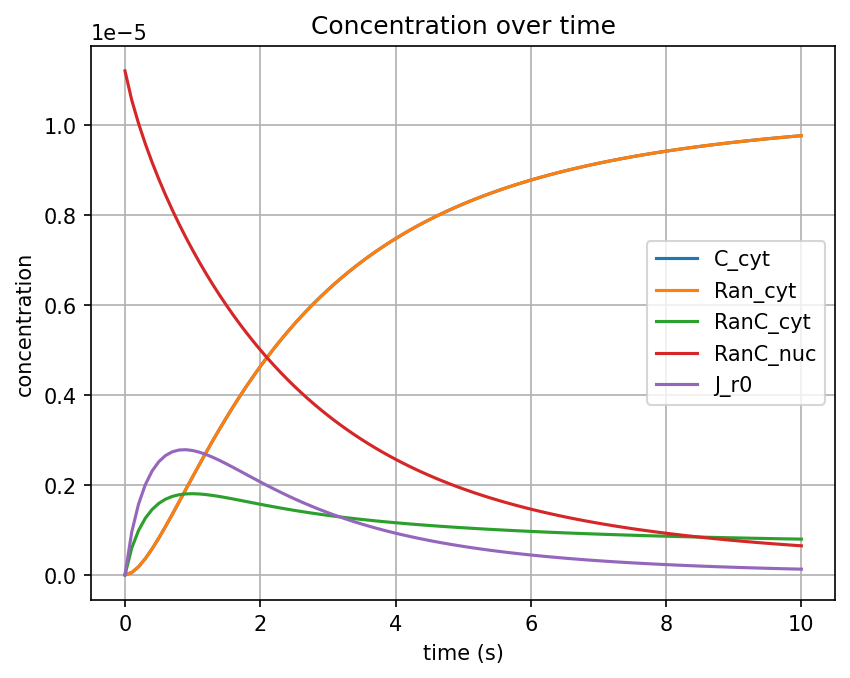

r0.Kf=4.829766986309707


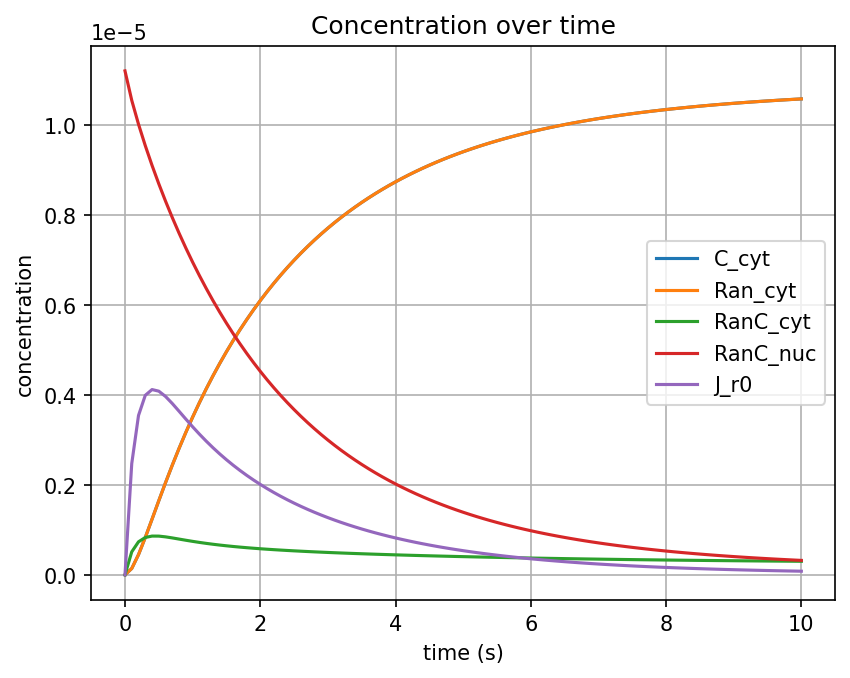

r0.Kf=1.1266941002336273


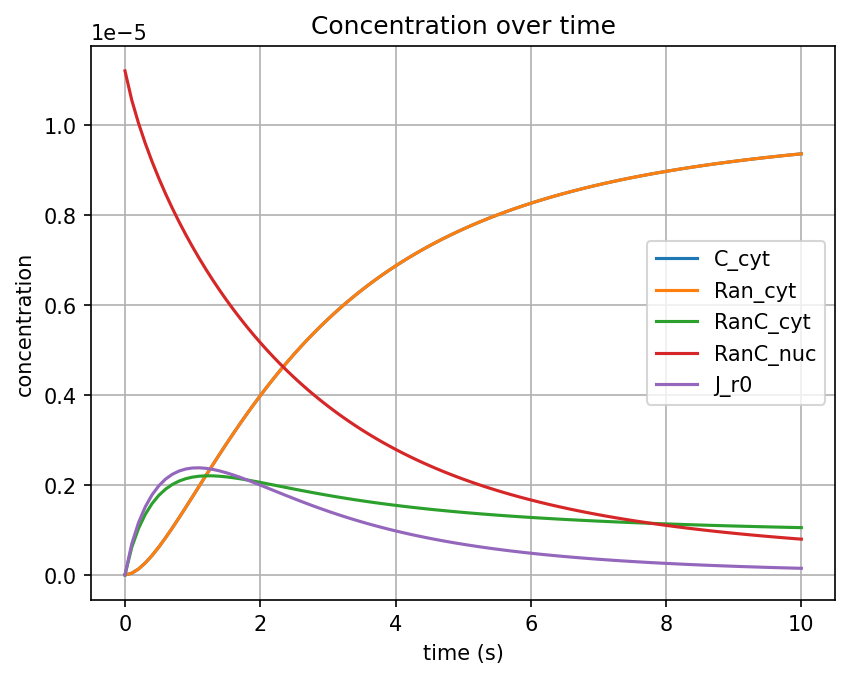

r0.Kf=1.6924814508056005


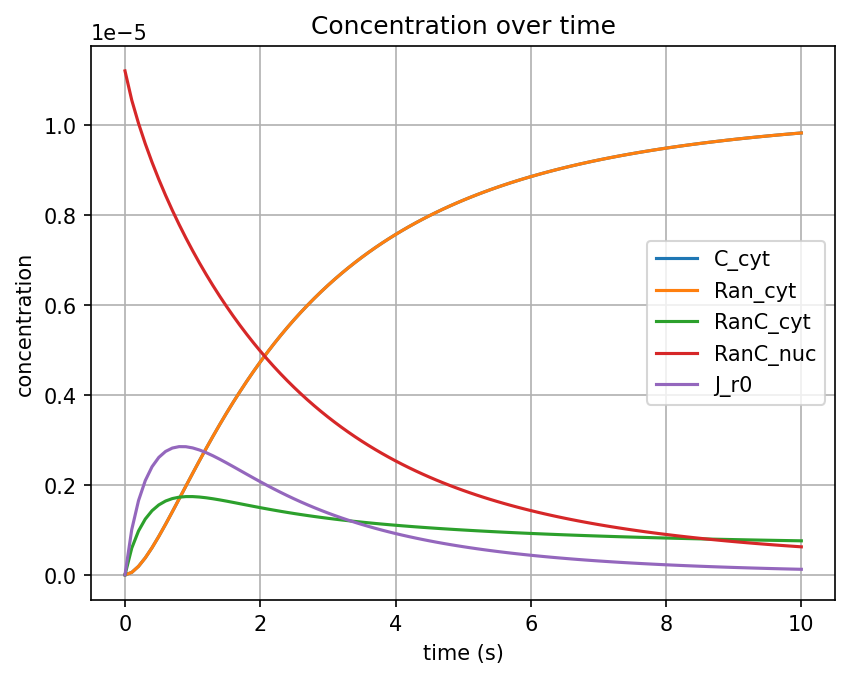

r0.Kf=0.30891448453410447


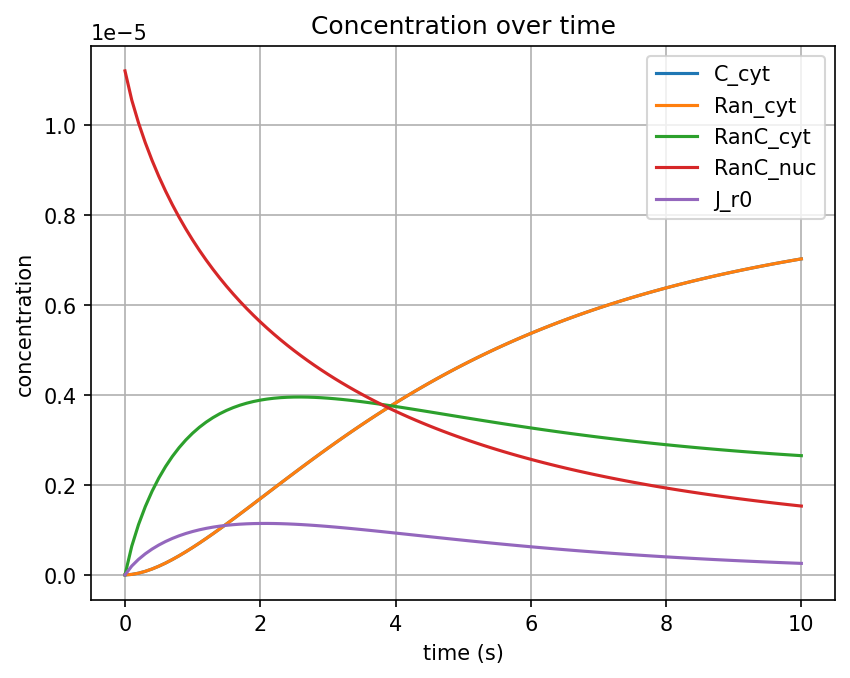

r0.Kf=3.5109627491740767


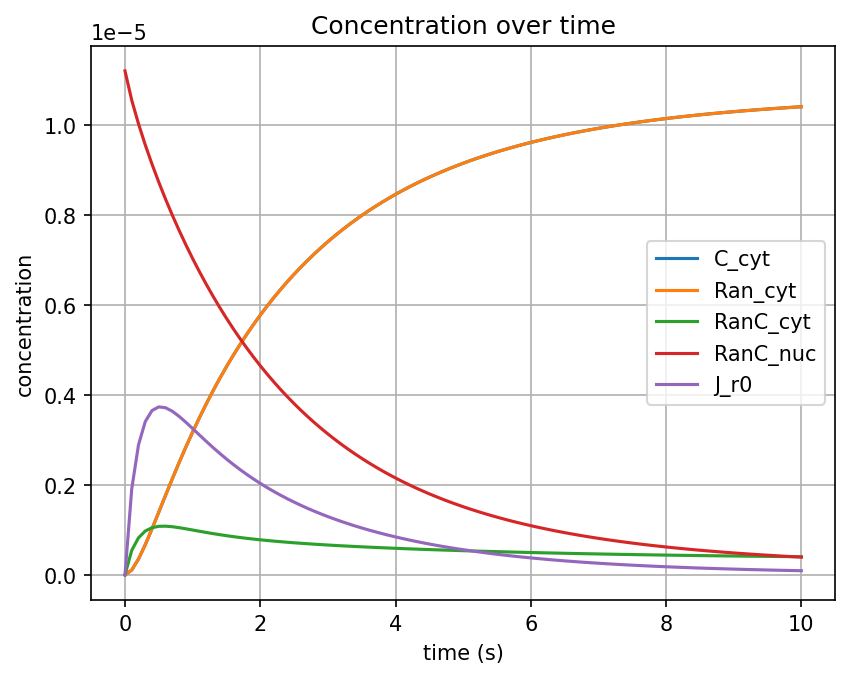

r0.Kf=0.5059998083531516


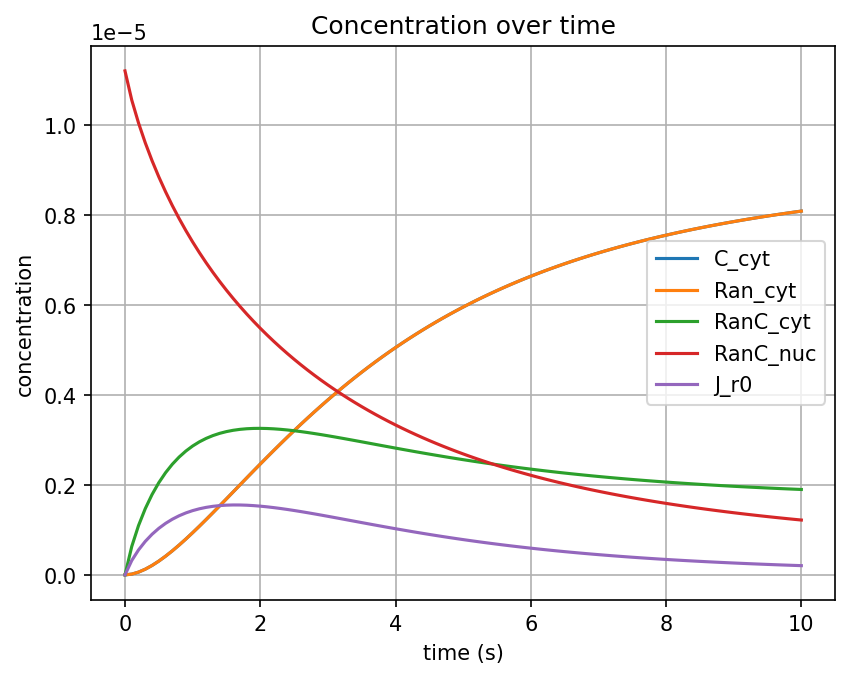

r0.Kf=1.0340456204866892


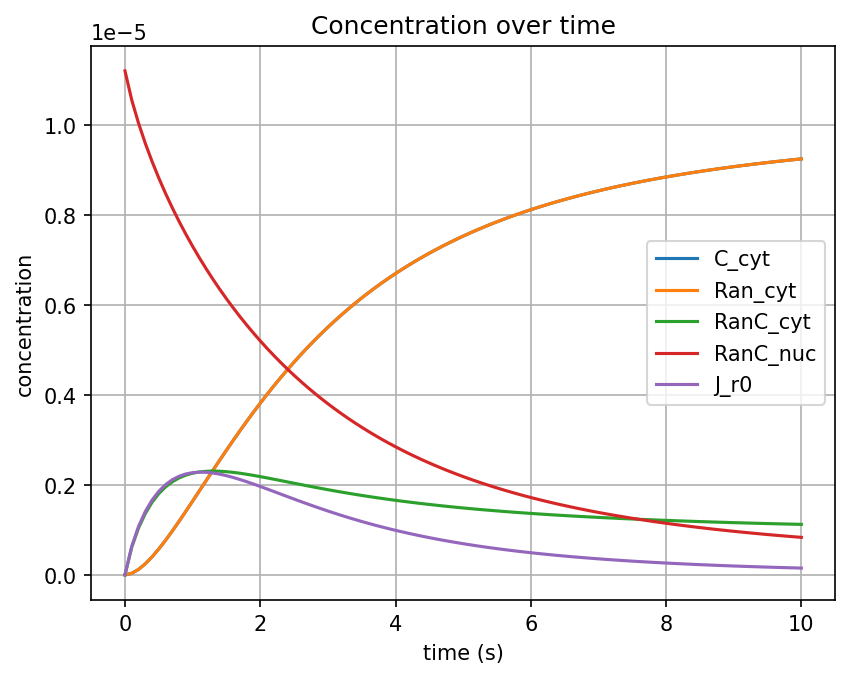

r0.Kf=0.44021092229024283


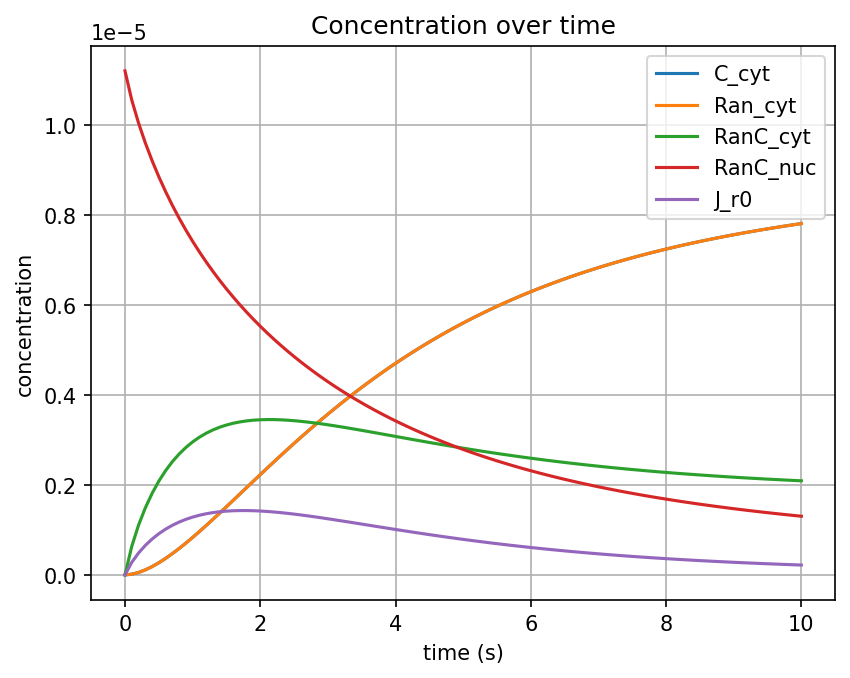

r0.Kf=2.7161175502471253


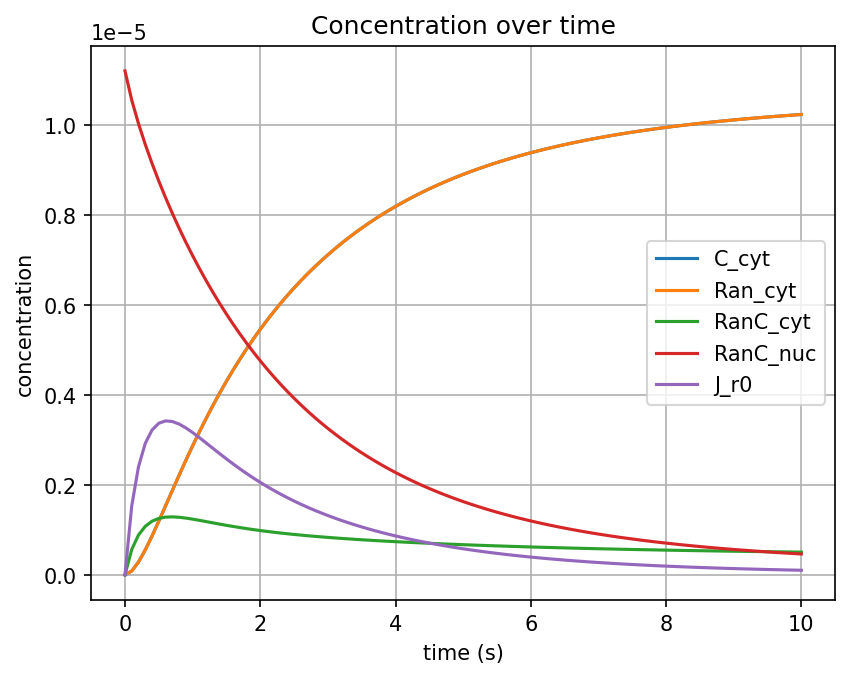

In [29]:
for i in range(N):
    val = r0_Kf_values[i]
    result = all_results[i]
    print(f"r0.Kf={val}")
    result.plotter.plot_concentrations()